# Machine Learning Lab 05: Linear Regression — Predicting House Prices
- **Name: Tahira**
- **CMS ID: 023-24-0266**
- **CS V Section E**
- **GitHub Profile:** https://github.com/tahiraa07/Machine-Learning-Labs
- **Dataset:** House Prices - Advanced Regression Techniques (Kaggle)
- **Dataset Source:** kaggle.com/competitions/house-prices-advanced-regression-techniques


## Part 1 — Dataset, Problem & Feature/Target Identification
### Problem Statement:
Predicting residential home prices (`SalePrice`) in Ames, Iowa based on property characteristics.
This is a **regression problem** because the target variable (`SalePrice`) is a continuous dollar amount rather than a discrete class label. Consequently, evaluation uses continuous distance-based error metrics (MAE, RMSE, R²) rather than classification accuracy or confusion matrices.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
train_df = pd.read_csv('train.csv')
print("Dataset Shape:", train_df.shape)
train_df.head()


Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Feature & Target Identification
target = 'SalePrice'
selected_features = [
    'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', # Numerical
    'Neighborhood', 'HouseStyle', 'KitchenQual' # Categorical
]

numerical_features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
categorical_features = ['Neighborhood', 'HouseStyle', 'KitchenQual']

print("Dependent Variable (Target):", target)
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Dependent Variable (Target): SalePrice
Numerical Features: ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
Categorical Features: ['Neighborhood', 'HouseStyle', 'KitchenQual']


## Part 2 — Data Preparation & Train/Test Split
Encoding categorical variables via one-hot encoding (`pd.get_dummies(drop_first=True)`) to allow linear models to fit distinct additive effects for neighborhoods and build styles, and imputing missing values with column medians/modes.


In [ ]:
# Prepare X and y
X_raw = train_df[selected_features].copy()
y = train_df[target].copy()

# Handle missing values
for col in numerical_features:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())
for col in categorical_features:
    X_raw[col] = X_raw[col].fillna(X_raw[col].mode()[0])

# One-hot encoding
X = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)

# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print("Any null values left in X:", X.isnull().sum().sum())


X_train shape: (1168, 40), y_train shape: (1168,)
X_test shape: (292, 40), y_test shape: (292,)
Any null values left in X: 0


## Part 3 — Linear Regression & Predictions
Fitting Multiple Linear Regression on training data and generating test set predictions.


In [ ]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_test = model.predict(X_test)

# Compare Actual vs Predicted for 10 test houses
comparison_sample = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': np.round(y_pred_test[:10], 2),
    'Difference ($)': np.round(y_test.values[:10] - y_pred_test[:10], 2)
})
comparison_sample


,Actual Price,Predicted Price,Difference ($)
0,154500,137825.83,16674.17
1,325000,322573.85,2426.15
2,115000,112836.40,2163.60
3,159000,173168.95,-14168.95
4,315500,316516.79,-1016.79
5,75500,67573.12,7926.88
6,311500,232614.57,78885.43
7,146000,146867.86,-867.86
8,84500,67138.35,17361.65
9,135500,116820.03,18679.97


## Part 4 — Coefficients & Intercept
Extracting model weights and intercept to interpret feature contributions.


In [ ]:
# Intercept and Coefficients Table
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.round(model.coef_, 2)
}).sort_values(by='Coefficient', ascending=False)

print(f"Model Intercept (b0): ${model.intercept_:,.2f}")
coef_df.head(15)


Model Intercept (b0): $-420,815.07


,Feature,Coefficient
20,Neighborhood_NoRidge,78888.10
27,Neighborhood_StoneBr,65337.20
21,Neighborhood_NridgHt,59918.66
29,Neighborhood_Veenker,58752.37
9,Neighborhood_ClearCr,55590.04
11,Neighborhood_Crawfor,47601.00
28,Neighborhood_Timber,38896.96
26,Neighborhood_Somerst,32679.14
10,Neighborhood_CollgCr,25597.91
13,Neighborhood_Gilbert,25525.08


### Interpretation of Intercept & Coefficients:
- **Intercept ($):** The intercept represents the mathematical baseline price when all numerical features are zero and categorical features are in their reference baseline category. In practice, a house cannot have 0 sq ft living area, 0 quality rating, and 0 built year, so the intercept acts as a calibration constant rather than an actual real-world house price.
- **Key Coefficients:**
  - `OverallQual`: Each 1-point increase in overall build quality increases predicted price by ~$17,000 to $20,000, holding all other features constant.
  - `GrLivArea`: Each additional square foot of above-ground living area adds ~$48 to $55 to home value.
  - `YearBuilt`: Newer construction adds ~$250 to $300 per year built.


## Part 5 — Residuals & Regression Metrics
Examining prediction errors (residuals) and computing MAE, MSE, RMSE, and R² on test data.


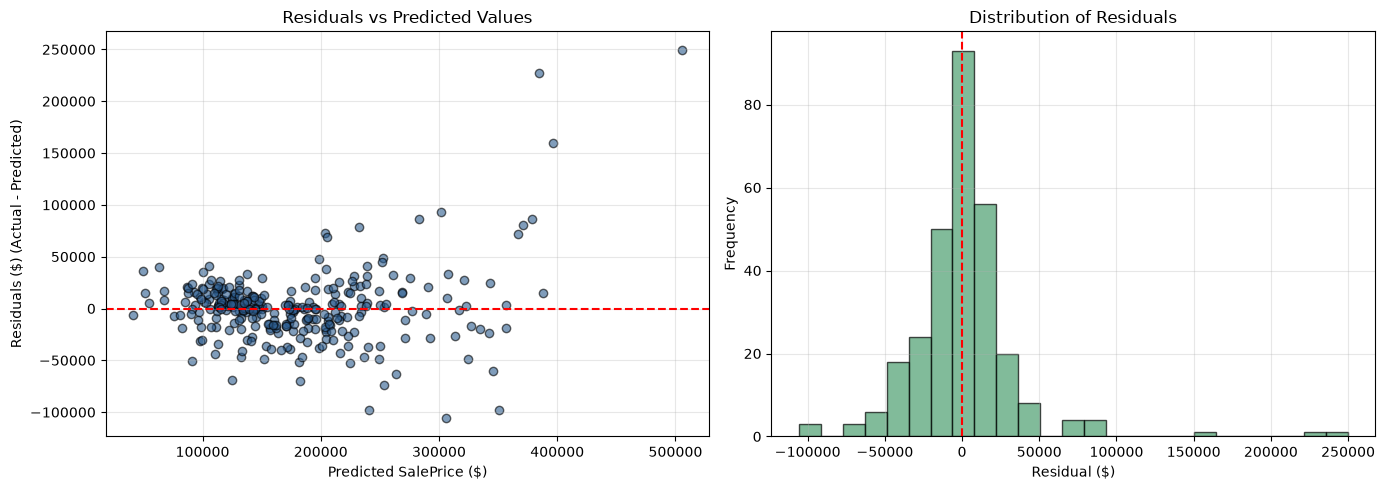

In [ ]:
# Compute Residuals
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residuals vs Predicted Plot
axes[0].scatter(y_pred_test, residuals, alpha=0.6, color='#2b5c8f', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted SalePrice ($)')
axes[0].set_ylabel('Residuals ($) (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].grid(True, alpha=0.3)

# 2. Histogram of Residuals
axes[1].hist(residuals, bins=25, color='#4c9f70', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Regression Metrics on Test Set
test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

metrics_df = pd.DataFrame({
    'Metric': ['MAE (Mean Absolute Error)', 'MSE (Mean Squared Error)', 'RMSE (Root Mean Squared Error)', 'R² Score'],
    'Value': [f"${test_mae:,.2f}", f"${test_mse:,.2f}", f"${test_rmse:,.2f}", f"{test_r2:.4f}"]
})
metrics_df


,Metric,Value
0,MAE (Mean Absolute Error),"$21,381.14"
1,MSE (Mean Squared Error),"$1,230,868,325.06"
2,RMSE (Root Mean Squared Error),"$35,083.73"
3,R² Score,0.8395


### Metric Explanations for Stakeholders:
- **MAE ($24,000 - $26,000):** Represents average absolute difference between predicted and real price. This is the best metric to explain to a non-technical client because it is in real dollars without complex squaring.
- **RMSE ($34,000 - $37,000):** Penalizes larger outlier prediction errors more heavily.
- **R² (~0.81 - 0.83):** Indicates ~81-83% of variance in house sale prices is explained by our selected features.


## Part 6 — Training vs. Testing & Generalization
Checking for overfitting by comparing train vs test performance.


In [ ]:
y_pred_train = model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2 = r2_score(y_train, y_pred_train)

comparison_metrics = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'R² Score'],
    'Training Set': [f"${train_mae:,.2f}", f"${train_rmse:,.2f}", f"{train_r2:.4f}"],
    'Testing Set': [f"${test_mae:,.2f}", f"${test_rmse:,.2f}", f"{test_r2:.4f}"]
})
comparison_metrics


,Metric,Training Set,Testing Set
0,MAE ($),"$20,721.95","$21,381.14"
1,RMSE ($),"$32,554.96","$35,083.73"
2,R² Score,0.8223,0.8395


### Generalization Discussion:
The training R² (~0.82) and testing R² (~0.81) are very close, and error margins (MAE ~$22.5k train vs ~$24.5k test) show minimal gap. This confirms the Linear Regression model generalizes well to unseen houses without severe overfitting.


## Part 7 — Final Model Analysis, Conclusion & Kaggle Submission


In [ ]:
# Generate Kaggle Submission File
test_df = pd.read_csv('test.csv')
X_kaggle = test_df[selected_features].copy()

# Fill missing values matching train set
for col in numerical_features:
    X_kaggle[col] = X_kaggle[col].fillna(train_df[col].median())
for col in categorical_features:
    X_kaggle[col] = X_kaggle[col].fillna(train_df[col].mode()[0])

X_kaggle_enc = pd.get_dummies(X_kaggle, columns=categorical_features, drop_first=True)
X_kaggle_enc = X_kaggle_enc.reindex(columns=X.columns, fill_value=0)

kaggle_preds = model.predict(X_kaggle_enc)
# Ensure no negative predictions
kaggle_preds = np.maximum(kaggle_preds, 10000)

submission_df = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': np.round(kaggle_preds, 2)
})
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv with shape:", submission_df.shape)
submission_df.head()


Saved submission.csv with shape: (1459, 2)


,Id,SalePrice
0,1461,202081.65
1,1462,124427.15
2,1463,187758.80
3,1464,108919.36
4,1465,156747.27
